In [3]:
import numpy as np
from tqdm import tqdm
import time
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 

# Code For Streaming Caratheodory's

In [20]:

def caratheodory(P, w, d):

    n = len(P)

    assert len(P) == len(w), "Length of points and weights must be the same"
    assert np.isclose(np.sum(w), 1), "Weights must sum to 1"
    assert n > d, "Number of points must be greater than dimension d"
    
    if n <= d + 1:
        return P, w
    
    p1 = P[0]
    A = np.array([P[i] - p1 for i in range(1, n)]).T
    try:
        v = null_space(A)
    except:
        return P, w
    v1 = -np.sum(v)
    v = np.insert(v, 0, v1)
    
    alpha = min([w[i] / v[i] for i in range(n) if v[i] > 0])
    u = np.array([w[i] - alpha * v[i] for i in range(n)])
    
    S = [P[i] for i in range(n) if u[i] > 0]
    u = [u[i] for i in range(n) if u[i] > 0]
    
    if len(S) > d + 1:
        return caratheodory(S, u, d)

    assert np.isclose(np.sum(u), 1), "Final weights must sum to 1"
    weighted_sum_original = np.dot(np.array(w), np.array(P))
    weighted_sum_reduced = np.dot(np.array(u), np.array(S))
    assert np.allclose(weighted_sum_original, weighted_sum_reduced), "Weighted sums must be preserved"
    
    return np.array(S), np.array(u)

def null_space(A, tol=1e-5):
    u, s, vh = np.linalg.svd(A)
    null_mask = (s <= tol)
    null_space = np.compress(null_mask, vh, axis=0)
    return null_space.T[:, 0]

# Set up the streaming algorithm
def streaming_caratheodory(P, w, d):
    print("Running streaming Caratheodory")
    n = len(P)
    selected_points = P[:d+1]
    selected_weights = np.array(w[:d+1])  # Convert to numpy array

    for i in tqdm(range(d+1, n)):
        selected_points = np.vstack((selected_points, P[i]))
        selected_weights = np.append(selected_weights, w[i])
        s1 = float(sum(selected_weights))
        selected_weights /= s1
    
        selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights), d)
        # print(selected_weights, s1)
        selected_weights=np.array(selected_weights) * s1  # Ensure selected_weights is numpy array before multiplying
        # selected_weights *= s1  # Ensure selected_weights is numpy array before multiplying
    return selected_points, selected_weights / sum(selected_weights)


### Function to calculate  Coreset for Matrix-2-Norm using Streaming Caratheodory's

In [5]:

def calculate_coreset_matrix_2_Norm(P_matrix):
    d_original=len(P_matrix[0])
    P_transformed=np.vstack([np.outer(r, r).flatten() for r in P_matrix])
    n=len(P_transformed)
    w=np.ones(n)/n
    coreset_points, coreset_weights=streaming_caratheodory(P_transformed, w,d_original*(d_original+1)//2)
    final_points=[]
    for i in range(len(coreset_points)):
        m1=coreset_points[i].reshape(d_original, d_original)
        x1=np.array([np.sqrt(x) for x in np.diag(m1)])*np.sqrt(coreset_weights[i])
        final_points.append(x1)
    final_points=np.array(final_points)
    return final_points



### Function to check the effectiveness of coreset

In [6]:
def check_corset(original, Coreset):
    original=original/np.sqrt(len(original))
    CoresetT=np.array(Coreset).T
    CTC=np.dot(CoresetT,Coreset)
    OTO=np.dot(original.T,original)
    flag=True
    for i in range(len(OTO)):
        for j in range(len(OTO[0])):
            if abs(OTO[i][j]-CTC[i][j])>0.0001:
                flag=False
                break
    return flag


### Function to add regularization to data

In [7]:
def  create_regularization_matrix(X, y,lambda_param):
    _, d= X.shape
    Id=np.identity(d)
    R_Id=Id*np.sqrt(lambda_param)
    A=np.hstack((X,y.reshape(-1,1)))
    B=np.hstack((R_Id,np.zeros((d,1))))
    return np.vstack((A,B))

### Function to fit the linear regression model and measure time

In [8]:
def fit_model(P, A_or, y_or):
    X=P[:,:-1]
    y=P[:,-1]
    start = time.perf_counter()
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    end = time.perf_counter()
    y_pred = A_or @ w
    rmse = np.sqrt(np.mean((y_or - y_pred) ** 2))
    return w, rmse,( end-start)*1000



## 1) Breast Cancer Dataset

### Pre-processsing the dataset and calculating the accurate coreset`

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_original.data.features 
y = breast_cancer_wisconsin_original.data.targets 
  
#handle missing values in X with mean
X=X.fillna(X.mean())
X = X.to_numpy()
y = y.to_numpy()
le = LabelEncoder()
y = le.fit_transform(y)


P_res=[]
Z_res=[]
coreset_sizes=[]
lambda_params=[10000,1000,500,100,10,5, 1, 0.1]
for lambda_param in tqdm(lambda_params, desc="Calcualting the coresets for different values of Lambda parameters"):
    P=create_regularization_matrix(X,y,lambda_param)
    Z=calculate_coreset_matrix_2_Norm(P)
    assert check_corset(P,Z)
    P_res.append(P)
    Z_res.append(Z)
    coreset_size=0
    for i in range(len(Z)):
        if len(Z[i][Z[i]>0])>1:
            coreset_size+=1
    coreset_sizes.append(coreset_size)

C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Calcualting the coresets for different values of Lambda parameters:   0%|          | 0/8 [00:00<?, ?it/s]

Running streaming Caratheodory


100%|██████████| 652/652 [00:02<00:00, 293.54it/s]
Calcualting the coresets for different values of Lambda parameters:  12%|█▎        | 1/8 [00:02<00:15,  2.24s/it]

Running streaming Caratheodory


100%|██████████| 652/652 [00:01<00:00, 357.45it/s]
Calcualting the coresets for different values of Lambda parameters:  25%|██▌       | 2/8 [00:04<00:12,  2.00s/it]

...

100%|██████████| 652/652 [00:02<00:00, 241.03it/s]
Calcualting the coresets for different values of Lambda parameters:  75%|███████▌  | 6/8 [00:12<00:04,  2.31s/it]

Running streaming Caratheodory


100%|██████████| 652/652 [00:01<00:00, 345.33it/s]
Calcualting the coresets for different values of Lambda parameters:  88%|████████▊ | 7/8 [00:14<00:02,  2.18s/it]

Running streaming Caratheodory


100%|██████████| 652/652 [00:01<00:00, 345.39it/s]
Calcualting the coresets for different values of Lambda parameters: 100%|██████████| 8/8 [00:16<00:00,  2.09s/it]


### Fitting the data and evaulating the results

Average time for full data: 0.9341875000927757
Average time for coreset data: 0.22770000020955194
Average RMSE for full data: 0.22579855059039888
Average RMSE for coreset data: 0.22579855059039888
Size of original Data: 708
Overall Coreset Size : 56
Dimension of Data : 10


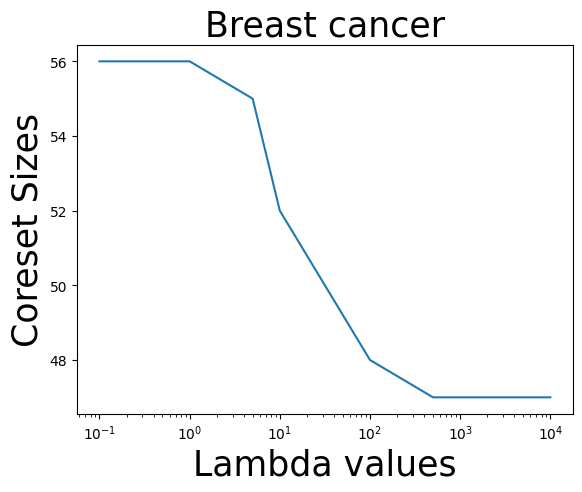

In [10]:

full_data_time=[]
full_data_rmse=[]
coreset_data_time=[]
coreset_data_rmse=[]
for i in range(len(P_res)):
    P=P_res[i]
    Z=Z_res[i]
    w, rmse, t1 = fit_model(P, X, y)    
    full_data_time.append(t1)
    full_data_rmse.append(rmse)
    w, rmse ,t2= fit_model(Z, X, y)
    coreset_data_time.append(t2)
    coreset_data_rmse.append(rmse)

print("Average time for full data:", sum(full_data_time)/len(full_data_time))
print("Average time for coreset data:", sum(coreset_data_time)/len(coreset_data_time))

data = {'Lambda': lambda_params, 'Full Data RMSE': full_data_rmse, 'Coreset Data RMSE': coreset_data_rmse}
df = pd.DataFrame(data)

print("Average RMSE for full data:", np.mean(full_data_rmse))
print("Average RMSE for coreset data:", np.mean(coreset_data_rmse))
print(f"Size of original Data: {len(P)}")
print(f"Overall Coreset Size : {len(Z)}")
print(f"Dimension of Data : {len(Z[0])}")


plt.plot(lambda_params, coreset_sizes)
plt.xlabel('Lambda values', fontsize=25)
plt.ylabel('Coreset Sizes', fontsize=25)
plt.title('Breast cancer', fontsize=25)
plt.xscale('log')
plt.show()




# 2)  Iris dataset

In [11]:
from ucimlrepo import fetch_ucirepo 

iris = fetch_ucirepo(id=53) 

X = iris.data.features 
y = iris.data.targets 

X = X.to_numpy()
y = y.to_numpy()
le = LabelEncoder()
y = le.fit_transform(y)

# Making different Matrices for different values of regularization
P_res=[]
Z_res=[]
coreset_sizes=[]
lambda_params=[10000,1000,500,100,10,5, 1, 0.1, 0.01, 0.001]
for lambda_param in tqdm(lambda_params):
    P=create_regularization_matrix(X,y,lambda_param)
    Z=calculate_coreset_matrix_2_Norm(P)
    assert check_corset(P,Z)
    P_res.append(P)
    Z_res.append(Z)
    coreset_size=0
    for i in range(len(Z)):
        if len(Z[i][Z[i]>0])>1:
            coreset_size+=1
    coreset_sizes.append(coreset_size)


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
  0%|          | 0/10 [00:00<?, ?it/s]

Running streaming Caratheodory


100%|██████████| 138/138 [00:00<00:00, 2262.83it/s]


Running streaming Caratheodory


 20%|██        | 2/10 [00:00<00:00, 15.73it/s]

...

 80%|████████  | 8/10 [00:00<00:00, 16.14it/s]

Running streaming Caratheodory


100%|██████████| 138/138 [00:00<00:00, 2493.37it/s]


Running streaming Caratheodory


100%|██████████| 10/10 [00:00<00:00, 16.08it/s]


Average time for full data: 0.17538000001877663
Average time for coreset data: 0.09333999996670173
Average RMSE for full data: 0.3392128751230167
Average RMSE for coreset data: 0.3392128751230166
Size of original Data: 154
Overall Coreset Size : 16
Dimension of Coreset : 5


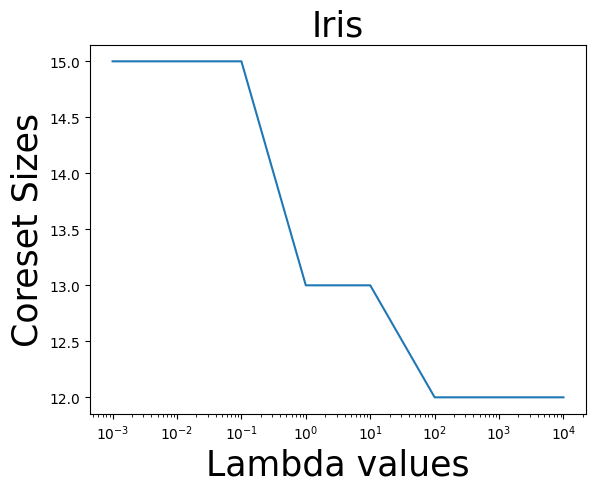

In [12]:
# for each model note down the time taken and the RMSE 
full_data_time=[]
full_data_rmse=[]
coreset_data_time=[]
coreset_data_rmse=[]
for i in range(len(P_res)):
    P=P_res[i]
    Z=Z_res[i]
    w, rmse, t1 = fit_model(P, X, y)    
    full_data_time.append(t1)
    full_data_rmse.append(rmse)
    w, rmse ,t2= fit_model(Z, X, y)
    coreset_data_time.append(t2)
    coreset_data_rmse.append(rmse)

# print average time for both cases
print("Average time for full data:", sum(full_data_time)/len(full_data_time))
print("Average time for coreset data:", sum(coreset_data_time)/len(coreset_data_time))

data = {'Lambda': lambda_params, 'Full Data RMSE': full_data_rmse, 'Coreset Data RMSE': coreset_data_rmse}
df = pd.DataFrame(data)

print("Average RMSE for full data:",np.mean(full_data_rmse))
print("Average RMSE for coreset data:", np.mean(coreset_data_rmse))

print(f"Size of original Data: {len(P)}")
print(f"Overall Coreset Size : {len(Z)}")
print(f"Dimension of Coreset : {len(Z[0])}")

plt.plot(lambda_params, coreset_sizes)
plt.xlabel('Lambda values', fontsize=25)
plt.ylabel('Coreset Sizes', fontsize=25)

# Increasing the size of the title
plt.title('Iris', fontsize=25)  # Adjust the value of fontsize as needed
plt.xscale('log')
plt.show()


# 3)  Glass Identification


###     Preparing the dataset

In [13]:

glass_identification = fetch_ucirepo(id=42) 
X = glass_identification.data.features 
y = glass_identification.data.targets 
X = X.to_numpy()
y = y.to_numpy()
le = LabelEncoder()
y = le.fit_transform(y)


P_res=[]
Z_res=[]
coreset_sizes=[]
lambda_params=[100,10,5, 2, 1, 0.5,  0.1, 0.01, 0.001]
for lambda_param in lambda_params:
    P=create_regularization_matrix(X,y,lambda_param)
    Z=calculate_coreset_matrix_2_Norm(P)
    assert check_corset(P,Z)
    P_res.append(P)
    Z_res.append(Z)
    coreset_size=0
    for i in range(len(Z)):
        if len(Z[i][Z[i]>0])>1:
            coreset_size+=1
    coreset_sizes.append(coreset_size)


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running streaming Caratheodory


100%|██████████| 167/167 [00:00<00:00, 318.33it/s]


Running streaming Caratheodory


100%|██████████| 167/167 [00:00<00:00, 351.48it/s]


...

100%|██████████| 167/167 [00:00<00:00, 324.95it/s]


Running streaming Caratheodory


100%|██████████| 167/167 [00:00<00:00, 331.02it/s]


Running streaming Caratheodory


100%|██████████| 167/167 [00:00<00:00, 345.60it/s]


### Fitting the model and getting evaluations

Average time for full data: 0.13203333350651925
Average time for coreset data: 0.11162222209451203
Average RMSE for full data: 0.8976594478278397
Average RMSE for coreset data: 0.8976595718195806
Size of the Entire Dataset :223
Overall Coreset Size : 56
Dimenion of dataset: 10


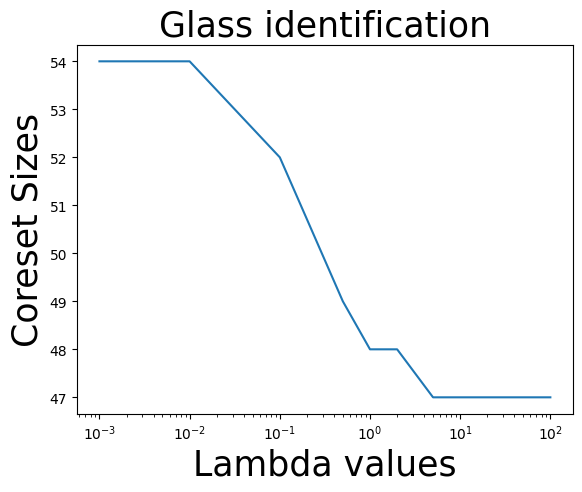

In [14]:
full_data_time=[]
full_data_rmse=[]
coreset_data_time=[]
coreset_data_rmse=[]
for i in range(len(P_res)):
    P=P_res[i]
    Z=Z_res[i]
    w, rmse, t1 = fit_model(P, X, y)    
    full_data_time.append(t1)
    full_data_rmse.append(rmse)
    w, rmse ,t2= fit_model(Z, X, y)
    coreset_data_time.append(t2)
    coreset_data_rmse.append(rmse)


# print average time for both cases
print("Average time for full data:", sum(full_data_time)/len(full_data_time))
print("Average time for coreset data:", sum(coreset_data_time)/len(coreset_data_time))


data = {'Lambda': lambda_params, 'Full Data RMSE': full_data_rmse, 'Coreset Data RMSE': coreset_data_rmse}
df = pd.DataFrame(data)

print("Average RMSE for full data:", np.mean(full_data_rmse))
print("Average RMSE for coreset data:",np.mean(coreset_data_rmse))

print(f"Size of the Entire Dataset :{len(P)}")
print(f"Overall Coreset Size : {len(Z)}")
print(f"Dimenion of dataset: {len(Z[0])}")

plt.plot(lambda_params, coreset_sizes)
plt.xlabel('Lambda values', fontsize=25)
plt.ylabel('Coreset Sizes', fontsize=25)

# Increasing the size of the title
plt.title('Glass identification', fontsize=25)  # Adjust the value of fontsize as needed
plt.xscale('log')
plt.show()


# Yeast Dataset

### Preparing the Data

In [15]:
yeast = fetch_ucirepo(id=110) 
X = yeast.data.features 
y = yeast.data.targets 
X = X.to_numpy()
y = y.to_numpy()
le = LabelEncoder()
y = le.fit_transform(y)


P_res=[]
Z_res=[]
coreset_sizes=[]
lambda_params=[10000,1000,100,10, 1, 0.1,0.005, 0.001, 0.0001]
for lambda_param in lambda_params:
    P=create_regularization_matrix(X,y,lambda_param)
    Z=calculate_coreset_matrix_2_Norm(P)
    assert check_corset(P,Z)
    P_res.append(P)
    Z_res.append(Z)
    coreset_size=0
    for i in range(len(Z)):
        if len(Z[i][Z[i]>0])>1:
            coreset_size+=1
    coreset_sizes.append(coreset_size)


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running streaming Caratheodory


100%|██████████| 1446/1446 [00:05<00:00, 258.80it/s]


Running streaming Caratheodory


100%|██████████| 1446/1446 [00:06<00:00, 221.14it/s]


...

100%|██████████| 1446/1446 [00:03<00:00, 432.34it/s]


Running streaming Caratheodory


100%|██████████| 1446/1446 [00:03<00:00, 429.54it/s]


Running streaming Caratheodory


100%|██████████| 1446/1446 [00:03<00:00, 435.87it/s]


### Fitting the data and doing the evaluation

Size of the full Data: 1492
Overall Coreset Size : 46
Dimension of Data : 9
Average time for full data: 0.17522222232299908
Average time for coreset data: 0.10281111099175178
Average RMSE for full data: 3.179607447010566
Average RMSE for coreset data: 3.179607447010566


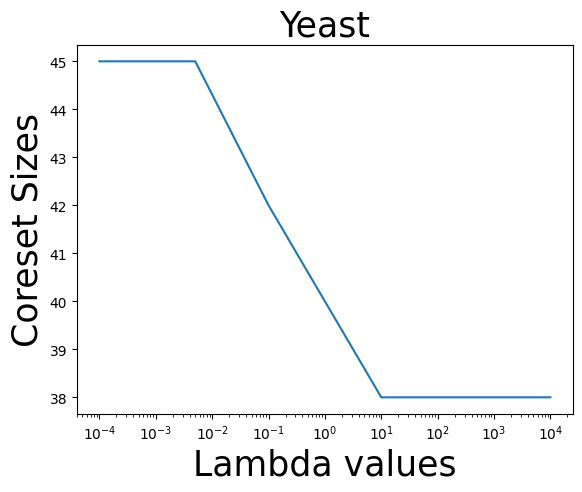

In [16]:

def fit_model(P, A_or, y_or):
    X=P[:,:-1]
    y=P[:,-1]
    # calculate argmin_w ||Xw-y||^2
    start = time.perf_counter()
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    end = time.perf_counter()
    # calculate the loss
    y_pred = A_or @ w
    rmse = np.sqrt(np.mean((y_or - y_pred) ** 2))
    return w, rmse,( end-start)*1000

# for each model note down the time taken and the RMSE 
full_data_time=[]
full_data_rmse=[]
coreset_data_time=[]
coreset_data_rmse=[]
for i in range(len(P_res)):
    P=P_res[i]
    Z=Z_res[i]
    w, rmse, t1 = fit_model(P, X, y)    
    full_data_time.append(t1)
    full_data_rmse.append(rmse)
    w, rmse ,t2= fit_model(Z, X, y)
    coreset_data_time.append(t2)
    coreset_data_rmse.append(rmse)


print(f"Size of the full Data: {len(P)}")
print(f"Overall Coreset Size : {len(Z)}")
print(f"Dimension of Data : {len(Z[0])}")


# print average time for both cases
print("Average time for full data:", sum(full_data_time)/len(full_data_time))
print("Average time for coreset data:", sum(coreset_data_time)/len(coreset_data_time))

data = {'Lambda': lambda_params, 'Full Data RMSE': full_data_rmse, 'Coreset Data RMSE': coreset_data_rmse}
df = pd.DataFrame(data)

print("Average RMSE for full data:", np.mean(full_data_rmse))
print("Average RMSE for coreset data:",np.mean(coreset_data_rmse))

plt.plot(lambda_params, coreset_sizes)
plt.xlabel('Lambda values', fontsize=25)
plt.ylabel('Coreset Sizes', fontsize=25)
# Increasing the size of the title
plt.title('Yeast', fontsize=25)  # Adjust the value of fontsize as needed
plt.xscale('log')
plt.show()

